In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import shutil, os

DRIVE_PATH = '/content/drive/MyDrive/Colab Notebooks/chirps-v3.0.1981-2026.colombia.nc'  # adjust if needed
LOCAL_PATH = "/content/chirps-v3.0.1981-2026.colombia.nc"

shutil.copy(DRIVE_PATH, LOCAL_PATH)
print("Copied to:", LOCAL_PATH)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Copied to: /content/chirps-v3.0.1981-2026.colombia.nc


In [1]:
!pip install climate-indices lmoments3 xarray netCDF4 -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.5/46.5 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.5/111.5 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.2/48.2 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 52.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 56.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 kB 3.9 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import xarray as xr
import scipy.stats as stats
from lmoments3 import distr
from climate_indices import indices, compute

## Load data and configuration of SPI parameters

In [ ]:
# Load the precipitation dataset
ds = xr.open_dataset(LOCAL_PATH)
ds = ds.drop_vars("spatial_ref", errors="ignore")

# Also remove any grid_mapping attribute pointing to it, so nothing tries to re-reference it
if "grid_mapping" in ds["precip"].attrs:
    del ds["precip"].attrs["grid_mapping"]

# Fix the units string so it matches what the spi CLI expects
ds["precip"].attrs["units"] = "mm"

clean_path = "/content/chirps-v3.0.1981-2026.colombia.cli_ready.nc"
ds.to_netcdf(clean_path)
print("Saved CLI-ready file:", clean_path)
print(ds)

da_precip = ds["precip"]

# --- Configuration ---
SPI_SCALE = 3
DISTRIBUTION = indices.Distribution.pearson
PERIODICITY = compute.Periodicity.monthly

DATA_START_YEAR = 1981          # first year of the input dataset
CALIB_START_YEAR = 1981         # calibration period start
CALIB_END_YEAR = 2025           # calibration period end (per your request)

OUTPUT_DIR = "/content/chirps_netcdf"  # reuse if already created earlier in your workflow
os.makedirs(OUTPUT_DIR, exist_ok=True)

# print(da_precip.dims)

Saved CLI-ready file: /content/chirps-v3.0.1981-2026.colombia.cli_ready.nc
<xarray.Dataset> Size: 252MB
Dimensions:  (time: 547, lat: 360, lon: 320)
Coordinates:
  * time     (time) datetime64[ns] 4kB 1981-01-01 1981-02-01 ... 2026-07-01
  * lat      (lat) float64 3kB 12.97 12.92 12.87 12.82 ... -4.875 -4.925 -4.975
  * lon      (lon) float64 3kB -81.97 -81.92 -81.87 ... -66.12 -66.07 -66.02
Data variables:
    precip   (time, lat, lon) float32 252MB ...
Attributes:
    source:   CHIRPS v3.0 monthly, LatAm subset


## calculate SPI and save the dataset

In [ ]:
# Stack lat/lon into a single 'pixel' dimension so we can loop per grid cell
da_precip_groupby = da_precip.stack(pixel=("lat", "lon")).groupby("pixel")

def calculate_spi(group):
    spi_values = indices.spi(
        group.values,
        SPI_SCALE,
        DISTRIBUTION,
        DATA_START_YEAR,
        CALIB_START_YEAR,
        CALIB_END_YEAR,
        PERIODICITY,
    )
    return xr.DataArray(spi_values, coords={"time": group.time}, dims=["time"])

# suppress verbose internal logging
import logging
logging.getLogger("climate_indices").setLevel(logging.WARNING)

In [ ]:
da_spi = da_precip_groupby.map(calculate_spi)
da_spi = da_spi.unstack("pixel")
da_spi.name = "spi_3_pearson"

Streaming output truncated to the last 5000 lines.
/usr/local/lib/python3.13/dist-packages/climate_indices/compute.py:830: GoodnessOfFitWarning: Pearson Type III distribution shows poor goodness-of-fit for 5 of 12 time steps (p < 0.05). Examples: step 7 (p=0.0343), step 8 (p=0.0468), step 9 (p=0.0066), step 10 (p=0.0155), step 11 (p=0.0327). Consider using a different distribution or investigating data quality issues.
  probabilities_of_zero, locs, scales, skews = pearson_parameters(
/usr/local/lib/python3.13/dist-packages/climate_indices/compute.py:830: GoodnessOfFitWarning: Pearson Type III distribution shows poor goodness-of-fit for 3 of 12 time steps (p < 0.05). Examples: step 7 (p=0.0270), step 8 (p=0.0043), step 10 (p=0.0342). Consider using a different distribution or investigating data quality issues.
  probabilities_of_zero, locs, scales, skews = pearson_parameters(
/usr/local/lib/python3.13/dist-packages/climate_indices/compute.py:830: GoodnessOfFitWarning: Pearson Type III d

In [ ]:
# Save with the same CF-compliant / R-friendly encoding used for the precip files
fill_value = -9999.0
ds_spi = da_spi.to_dataset()
ds_spi["spi_3_pearson"] = ds_spi["spi_3_pearson"].fillna(fill_value)
ds_spi["spi_3_pearson"].attrs["missing_value"] = fill_value
ds_spi["spi_3_pearson"].attrs["long_name"] = "3-month SPI (Pearson Type III)"
ds_spi["spi_3_pearson"].attrs["units"] = "unitless"
ds_spi.attrs["calibration_period"] = f"{CALIB_START_YEAR}-{CALIB_END_YEAR}"

encoding = {
    "spi_3_pearson": {"_FillValue": fill_value, "dtype": "float32", "zlib": True, "complevel": 4},
    "time": {"dtype": "float64"},
}

spi_out_path = os.path.join(OUTPUT_DIR, "chirps-v3.0.spi3_pearson.1981-2026.colombia.nc")
ds_spi.to_netcdf(spi_out_path, engine="netcdf4", encoding=encoding, format="NETCDF4")
print(f"Saved: {spi_out_path}")

Saved: /content/chirps_netcdf/chirps-v3.0.spi3_pearson.1981-2026.colombia.nc


In [ ]:
# !spi \
#   --periodicity monthly \
#   --netcdf_precip "{clean_path}" \
#   --var_name_precip precip \
#   --output_file_base /content/chirps_netcdf/colombia \
#   --scales 3 \
#   --calibration_start_year 1981 \
#   --calibration_end_year 2025 \
#   --multiprocessing single \
#   --save_params /content/chirps_netcdf/colombia_spi3_fitting_params.nc \
#   --overwrite

2026-08-25T02:20:11.910877Z [info     ] Start time:    2026-08-25 02:20:11.910570 [climate_indices.__spi__]
2026-08-25T02:20:12.147555Z [info     ] Computing monthly SPI          [climate_indices.__spi__]
2026-08-25T02:20:14.861347Z [info     ] Computing 3-month SPI (Gamma)  [climate_indices.__spi__]
2026-08-25T02:20:14.875960Z [info     ] distribution_fitting_started   [climate_indices.compute] calibration_period=1981-2025 distribution=gamma operation=gamma_parameters periodicity=monthly
2026-08-25T02:20:14.877380Z [info     ] distribution_fitting_started   [climate_indices.compute] calibration_period=1981-2025 distribution=gamma operation=gamma_parameters periodicity=monthly
2026-08-25T02:20:14.877626Z [info     ] distribution_fitting_started   [climate_indices.compute] calibration_period=1981-2025 distribution=gamma operation=gamma_parameters periodicity=monthly
2026-08-25T02:20:14.877890Z [info     ] distribution_fitting_started   [climate_indices.compute] calibration_period=1981-2

## Categorisation

In [ ]:
# Load your SPI-3 result
spi_path = "/content/chirps-v3.0.spi3_pearson.1981-2026.colombia.nc"
ds_spi = xr.open_dataset(spi_path)

spi = ds_spi["spi_3_pearson"]

# Restore NaN where the fill value was used, so nodata doesn't get miscategorized
fill_value = -9999.0
spi_clean = spi.where(spi != fill_value)

# Define categories in order (order matters for np.select - first match wins)
conditions = [
    spi_clean > 2, (spi_clean > 1.5) & (spi_clean <= 2), (spi_clean > 1) & (spi_clean <= 1.5),
    (spi_clean > -1) & (spi_clean <= 1),
    (spi_clean > -1.5) & (spi_clean <= -1), (spi_clean > -2) & (spi_clean <= -1.5), spi_clean <= -2,
]

category_codes = [1, 2, 3, 4, 5, 6, 7]
category_labels = [
    "extremely wet",    "severely wet",    "moderately wet",
    "normal",
    "moderately dry",    "severely dry",    "extremely dry",
]

nodata_code = 255  # reserved code for missing/nodata pixels

# Apply the classification
category_data = np.select(
    [c.values for c in conditions],
    category_codes,
    default=nodata_code,
)

# Wherever the original SPI was NaN, force the category back to nodata
# (np.select's conditions all evaluate False for NaN comparisons, so this
# is already handled by `default`, but we make it explicit for clarity)
category_data = np.where(np.isnan(spi_clean.values), nodata_code, category_data)

da_category = xr.DataArray(
    category_data.astype(np.uint8),
    dims=spi_clean.dims,
    coords=spi_clean.coords,
    name="spi3_category",
)

In [ ]:
ds_category = da_category.to_dataset()

ds_category["spi3_category"].attrs = {
    "long_name": "SPI-3 drought/wetness category",
    "flag_values": np.array(category_codes + [nodata_code], dtype=np.uint8),
    "flag_meanings": " ".join(label.replace(" ", "_") for label in category_labels) + " nodata",
    "_FillValue": np.uint8(nodata_code),
    "lookup_table": (
        "1=extremely wet (SPI>2); 2=severely wet (1.5<SPI<=2); "
        "3=moderately wet (1<SPI<=1.5); 4=normal (-1<SPI<=1); "
        "5=moderately dry (-1.5<SPI<=-1); 6=severely dry (-2<SPI<=-1.5); "
        "7=extremely dry (SPI<=-2); 255=nodata"
    ),
}
ds_category.attrs["source"] = "Derived from SPI-3 Pearson Type III, CHIRPS v3.0"
ds_category.attrs["calibration_period"] = ds_spi.attrs.get("calibration_period", "")

encoding_category = {
    "spi3_category": {"dtype": "uint8", "zlib": True, "complevel": 4}
}

category_out_path = "/content/chirps-v3.0.spi3_pearson_category.1981-2026.colombia.nc"
ds_category.to_netcdf(category_out_path, engine="netcdf4", encoding=encoding_category, format="NETCDF4")
print(f"Saved: {category_out_path}")

Saved: /content/chirps-v3.0.spi3_pearson_category.1981-2026.colombia.nc


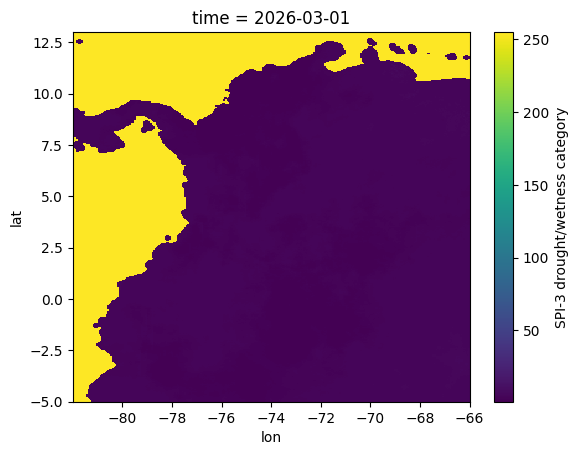

In [ ]:
# print(ds_category["spi3_category"].sel(time="2026-03-01").values)
# ds_category["spi3_category"].sel(time="2026-03-01").plot()

## Fit and save the Pearson Type III parameters

In [ ]:
def fit_pearson3_params(values_1d, dates, scale, calib_start_year, calib_end_year):
    values_1d = np.asarray(values_1d, dtype=float).ravel()  # <- added: force clean 1-D array

    scaled = compute.sum_to_scale(values_1d, scale)
    s = pd.Series(scaled, index=pd.to_datetime(dates))
    calib = s[(s.index.year >= calib_start_year) & (s.index.year <= calib_end_year)]

    prob_zero = np.full(12, np.nan)
    loc = np.full(12, np.nan)
    scl = np.full(12, np.nan)
    skew = np.full(12, np.nan)

    for m in range(1, 13):
        month_vals = calib[calib.index.month == m].values
        month_vals = month_vals[~np.isnan(month_vals)]
        if month_vals.size == 0:
            continue
        prob_zero[m - 1] = np.sum(month_vals <= 0) / month_vals.size
        nonzero_vals = month_vals[month_vals > 0]
        if nonzero_vals.size >= 4:
            try:
                params = distr.pe3.lmom_fit(nonzero_vals)
                loc[m - 1] = params["loc"]
                scl[m - 1] = params["scale"]
                skew[m - 1] = params["skew"]
            except Exception:
                pass

    return prob_zero, loc, scl, skew


def fit_pixel(group):
    prob_zero, loc, scl, skew = fit_pearson3_params(
        group.values, group.time.values, SPI_SCALE, CALIB_START_YEAR, CALIB_END_YEAR
    )
    return xr.Dataset(
        {
            "prob_zero": ("month", prob_zero),
            "loc": ("month", loc),
            "scale": ("month", scl),
            "skew": ("month", skew),
        },
        coords={"month": np.arange(1, 13)},
    )

In [ ]:
ds_params = da_precip_groupby.map(fit_pixel)
ds_params = ds_params.unstack("pixel")
ds_params.attrs["distribution"] = "pearson3"
ds_params.attrs["scale_months"] = SPI_SCALE
ds_params.attrs["calibration_period"] = f"{CALIB_START_YEAR}-{CALIB_END_YEAR}"

# Save (no need for the -9999 fill-value trick here since these params are for
# reuse in Python, not for visual inspection in R, but we keep it consistent anyway)
encoding_params = {
    var: {"_FillValue": np.nan, "dtype": "float64", "zlib": True, "complevel": 4}
    for var in ["prob_zero", "loc", "scale", "skew"]
}

params_out_path = os.path.join(OUTPUT_DIR, "chirps-v3.0.spi3_pearson_params.1981-2025.colombia.nc")
ds_params.to_netcdf(params_out_path, engine="netcdf4", encoding=encoding_params, format="NETCDF4")
print(f"Saved: {params_out_path}")

Saved: /content/chirps_netcdf/chirps-v3.0.spi3_pearson_params.1981-2025.colombia.nc


In [ ]:
import shutil

# Define your source file and target destination in Drive
source_file = "/content/chirps_netcdf/chirps-v3.0.spi3_pearson_params.1981-2025.colombia.nc"
destination_path = "/content/drive/MyDrive/chirps-v3.0.spi3_pearson_params.1981-2025.colombia.nc"

# Copy the file
shutil.copy(source_file, destination_path)
print("File uploaded successfully!")


File uploaded successfully!


## compute March 2026 SPI-3 from just Jan–Mar 2026, and compare

In [ ]:
ds_params_loaded = xr.open_dataset(params_out_path)

precip_jfm_2026 = da_precip.sel(time=slice("2026-01-01", "2026-03-31"))
assert precip_jfm_2026.sizes["time"] == 3

precip_3month_mar2026 = precip_jfm_2026.sum(dim="time", skipna=False)
march_params = ds_params_loaded.sel(month=3)

def pearson3_to_spi(x, prob_zero, loc, scale, skew):
    x = np.asarray(x, dtype=float)
    prob_zero = np.asarray(prob_zero, dtype=float)
    loc = np.asarray(loc, dtype=float)
    scale = np.asarray(scale, dtype=float)
    skew = np.asarray(skew, dtype=float)
    cdf = np.where(
        x <= 0,
        prob_zero,
        prob_zero + (1.0 - prob_zero) * stats.pearson3.cdf(x, skew, loc, scale),
    )
    cdf = np.clip(cdf, 1e-6, 1 - 1e-6)
    z = stats.norm.ppf(cdf)
    return np.clip(z, -3.09, 3.09)

spi_mar2026_manual = xr.apply_ufunc(
    pearson3_to_spi,
    precip_3month_mar2026,
    march_params["prob_zero"],
    march_params["loc"],
    march_params["scale"],
    march_params["skew"],
    vectorize=True,
)

spi_mar2026_full = ds_spi["spi_3_pearson"].sel(time="2026-03-01")
difference = (spi_mar2026_manual - spi_mar2026_full.values).values
print("Max absolute difference:", np.nanmax(np.abs(difference)))
print("Mean absolute difference:", np.nanmean(np.abs(difference)))

# add the newly available time step and calculate the SPI

In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import scipy.stats as stats

combined_out_path = "/content/chirps_netcdf/chirps-v3.0.1981-2026-08.monthly.colombia.nc"
params_out_path = "/content/chirps_netcdf/chirps-v3.0.spi3_pearson_params.1981-2025.colombia.nc"
spi_out_path = "/content/chirps_netcdf/chirps-v3.0.spi3_pearson.1981-2026-08.colombia.nc"
category_out_path = "/content/chirps_netcdf/chirps-v3.0.spi3_pearson_category.1981-2026-08.colombia.nc"

fill_value = -9999.0

# 1. Full CHIRPS precipitation dataset (now including August 2026)
ds_precip_full = xr.open_dataset(combined_out_path)
# ds_precip_full = ds_precip_full.isel(time=slice(None, -1))
ds_precip_full["precip"] = ds_precip_full["precip"].where(ds_precip_full["precip"] != fill_value)

# 2. Pearson III fitting parameters (from calibration period 1981-2025)
ds_params = xr.open_dataset(params_out_path)

# 3. Existing SPI-3 time series (currently ends July 2026)
ds_spi_existing = xr.open_dataset(spi_out_path)
ds_spi_existing = ds_spi_existing.isel(time = slice(None, -1))

ds_spi_existing["spi_3_pearson"] = ds_spi_existing["spi_3_pearson"].where(
    ds_spi_existing["spi_3_pearson"] != fill_value
)

# 4. Existing categorized dataset (keep raw uint8 codes, don't auto-mask to float)
ds_category_existing = xr.open_dataset(category_out_path, mask_and_scale=False)
ds_category_existing = ds_category_existing.isel(time = slice(None, -1))

print("Precip range:", ds_precip_full.time.min().values, "to", ds_precip_full.time.max().values)
print("Existing SPI range:", ds_spi_existing.time.min().values, "to", ds_spi_existing.time.max().values)
print("Existing category range:", ds_category_existing.time.min().values, "to", ds_category_existing.time.max().values)

Precip range: 1981-01-01T00:00:00.000000000 to 2026-08-01T00:00:00.000000000
Existing SPI range: 1981-01-01T00:00:00.000000000 to 2026-07-01T00:00:00.000000000
Existing category range: 1981-01-01T00:00:00.000000000 to 2026-07-01T00:00:00.000000000


In [2]:
# ds_category_existing["spi3_category"].sel(time="2026-07-01").plot()
# ds_precip_full["precip"].sel(time="2026-08-01").plot()
# ds_spi_existing["spi_3_pearson"].sel(time="2026-07-01").plot()
# ds_params["loc"].sel(month=8).plot()

Compute newly acquired time step

In [3]:
# SPI-3 for August needs the 3-month accumulated precip: June + July + August 2026
precip_jja_2026 = ds_precip_full["precip"].sel(time=slice("2026-06-01", "2026-08-31"))
assert precip_jja_2026.sizes["time"] == 3, "Expected exactly 3 months (Jun-Aug 2026)"

precip_3month_aug2026 = precip_jja_2026.sum(dim="time", skipna=False)

# Confirm the orientation difference between Precip and Params (for your own understanding)
print("Precip lat direction:", "descending" if ds_precip_full.lat.values[0] > ds_precip_full.lat.values[-1] else "ascending")
print("Params lat direction:", "descending" if ds_params.lat.values[0] > ds_params.lat.values[-1] else "ascending")

# Correct alignment: lat or lon value-based, not array position-based
ds_params_aligned = ds_params.reindex(
    lat=ds_precip_full.lat,
    lon=ds_precip_full.lon,
    method="nearest",
    tolerance=1e-3,
)

# Pull August's fitted parameters (calendar month = 8) for every pixel
august_params = ds_params_aligned.sel(month=8)
# august_params["loc"].plot()

def pearson3_to_spi(x, prob_zero, loc, scale, skew):
    x = np.asarray(x, dtype=float)
    prob_zero = np.asarray(prob_zero, dtype=float)
    loc = np.asarray(loc, dtype=float)
    scale = np.asarray(scale, dtype=float)
    skew = np.asarray(skew, dtype=float)
    cdf = np.where(
        x <= 0,
        prob_zero,
        prob_zero + (1.0 - prob_zero) * stats.pearson3.cdf(x, skew, loc, scale),
    )
    cdf = np.clip(cdf, 1e-6, 1 - 1e-6)
    z = stats.norm.ppf(cdf)
    return np.clip(z, -3.09, 3.09)

spi_aug2026 = xr.apply_ufunc(
    pearson3_to_spi,
    precip_3month_aug2026,
    august_params["prob_zero"],
    august_params["loc"],
    august_params["scale"],
    august_params["skew"],
    vectorize=True,
)

# Give it a time dimension/coordinate so it can be concatenated
spi_aug2026 = spi_aug2026.expand_dims(time=[pd.Timestamp("2026-08-01")])
spi_aug2026.name = "spi_3_pearson"
# spi_aug2026["spi_3_pearson"].sel(time = "2026-08-01").plot()

Precip lat direction: descending
Params lat direction: ascending


In [4]:
# precip_3month_aug2026.plot()
# spi_aug2026.sel(time = "2026-08-01").plot()
# august_params["loc"].plot()
# spi_aug2026


join and save new SPI

In [6]:
# Join with the existing SPI dataset
ds_spi_updated = xr.concat([ds_spi_existing, spi_aug2026.to_dataset()], dim="time")
ds_spi_updated = ds_spi_updated.sortby("time")

# Safety check: no duplicate time steps
_, unique_idx = np.unique(ds_spi_updated["time"].values, return_index=True)
if len(unique_idx) != ds_spi_updated.sizes["time"]:
    print("Warning: duplicate time steps found, keeping only the first occurrence.")
    ds_spi_updated = ds_spi_updated.isel(time=sorted(unique_idx))

print("Updated SPI range:", ds_spi_updated.time.min().values, "to", ds_spi_updated.time.max().values)

# Save with the same CF-compliant encoding used before
ds_spi_updated["spi_3_pearson"] = ds_spi_updated["spi_3_pearson"].fillna(fill_value)
ds_spi_updated["spi_3_pearson"].attrs["missing_value"] = fill_value
ds_spi_updated["spi_3_pearson"].attrs["long_name"] = "3-month SPI (Pearson Type III)"
ds_spi_updated["spi_3_pearson"].attrs["units"] = "unitless"
ds_spi_updated.attrs["calibration_period"] = ds_spi_existing.attrs.get("calibration_period", "1981-2025")

encoding_spi = {
    "spi_3_pearson": {"_FillValue": fill_value, "dtype": "float32", "zlib": True, "complevel": 4},
    "time": {"dtype": "float64"},
}

ds_spi_existing.close()
spi_updated_out_path = "/content/chirps_netcdf/chirps-v3.0.spi3_pearson.1981-2026-08.colombia.nc"
ds_spi_updated.to_netcdf(spi_updated_out_path, engine="netcdf4", encoding=encoding_spi, format="NETCDF4", mode='w')
print(f"Saved: {spi_updated_out_path}")

/tmp/ipykernel_14016/736140282.py:2: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'lat' ('lat',) The recommendation is to set join explicitly for this case.
  ds_spi_updated = xr.concat([ds_spi_existing, spi_aug2026.to_dataset()], dim="time")


Updated SPI range: 1981-01-01T00:00:00.000000000 to 2026-08-01T00:00:00.000000000
Saved: /content/chirps_netcdf/chirps-v3.0.spi3_pearson.1981-2026-08.colombia.nc


categorize new time step

In [7]:
category_codes = [1, 2, 3, 4, 5, 6, 7]
category_labels = [
    "extremely wet",
    "severely wet",
    "moderately wet",
    "normal",
    "moderately dry",
    "severely dry",
    "extremely dry",
]
nodata_code = 255

def categorize_spi(spi_da):
    conditions = [
        spi_da > 2,
        (spi_da > 1.5) & (spi_da <= 2),
        (spi_da > 1) & (spi_da <= 1.5),
        (spi_da > -1) & (spi_da <= 1),
        (spi_da > -1.5) & (spi_da <= -1),
        (spi_da > -2) & (spi_da <= -1.5),
        spi_da <= -2,
    ]
    category_data = np.select([c.values for c in conditions], category_codes, default=nodata_code)
    category_data = np.where(np.isnan(spi_da.values), nodata_code, category_data)
    return xr.DataArray(
        category_data.astype(np.uint8),
        dims=spi_da.dims,
        coords=spi_da.coords,
        name="spi3_category",
    )

# Categorize just the August 2026 slice
spi_aug2026_only = ds_spi_updated["spi_3_pearson"].sel(time="2026-08-01")
spi_aug2026_only = spi_aug2026_only.where(spi_aug2026_only != fill_value)  # ensure NaN, not the raw fill number
category_aug2026 = categorize_spi(spi_aug2026_only)
category_aug2026 = category_aug2026.expand_dims(time=[pd.Timestamp("2026-08-01")])

join and save new categorised

In [8]:
# Join with the existing categorized dataset
ds_category_updated = xr.concat([ds_category_existing, category_aug2026.to_dataset()], dim="time")
ds_category_updated = ds_category_updated.sortby("time")

# Safety check: no duplicate time steps
_, unique_idx = np.unique(ds_category_updated["time"].values, return_index=True)
if len(unique_idx) != ds_category_updated.sizes["time"]:
    print("Warning: duplicate time steps found, keeping only the first occurrence.")
    ds_category_updated = ds_category_updated.isel(time=sorted(unique_idx))

print("Updated category range:", ds_category_updated.time.min().values, "to", ds_category_updated.time.max().values)

# Preserve the same CF metadata as before
ds_category_updated["spi3_category"].attrs = {
    "long_name": "SPI-3 drought/wetness category",
    "flag_values": np.array(category_codes + [nodata_code], dtype=np.uint8),
    "flag_meanings": " ".join(label.replace(" ", "_") for label in category_labels) + " nodata",
    "_FillValue": np.uint8(nodata_code),
    "lookup_table": (
        "1=extremely wet (SPI>2); 2=severely wet (1.5<SPI<=2); "
        "3=moderately wet (1<SPI<=1.5); 4=normal (-1<SPI<=1); "
        "5=moderately dry (-1.5<SPI<=-1); 6=severely dry (-2<SPI<=-1.5); "
        "7=extremely dry (SPI<=-2); 255=nodata"
    ),
}
ds_category_updated.attrs["source"] = "Derived from SPI-3 Pearson Type III, CHIRPS v3.0"
ds_category_updated.attrs["calibration_period"] = ds_category_existing.attrs.get("calibration_period", "")

encoding_category = {"spi3_category": {"dtype": "uint8", "zlib": True, "complevel": 4}}

ds_category_existing.close()
category_updated_out_path = "/content/chirps_netcdf/chirps-v3.0.spi3_pearson_category.1981-2026-08.colombia.nc"
ds_category_updated.to_netcdf(
    category_updated_out_path, engine="netcdf4", encoding=encoding_category, format="NETCDF4"
)
print(f"Saved: {category_updated_out_path}")

Updated category range: 1981-01-01T00:00:00.000000000 to 2026-08-01T00:00:00.000000000
Saved: /content/chirps_netcdf/chirps-v3.0.spi3_pearson_category.1981-2026-08.colombia.nc
